### 1. Import library

In [36]:
import os
import sys
import io
from pathlib import Path
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


### 2.Prepare Data

In [ ]:
ROOT_DIR = os.getcwd()
DATA_DIR = os.path.join(ROOT_DIR, "orgdata")
OUT_DIR  = os.path.join(ROOT_DIR, "cleandata")

train = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"), parse_dates=['Date'])
test = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"), parse_dates=['Date'])
 


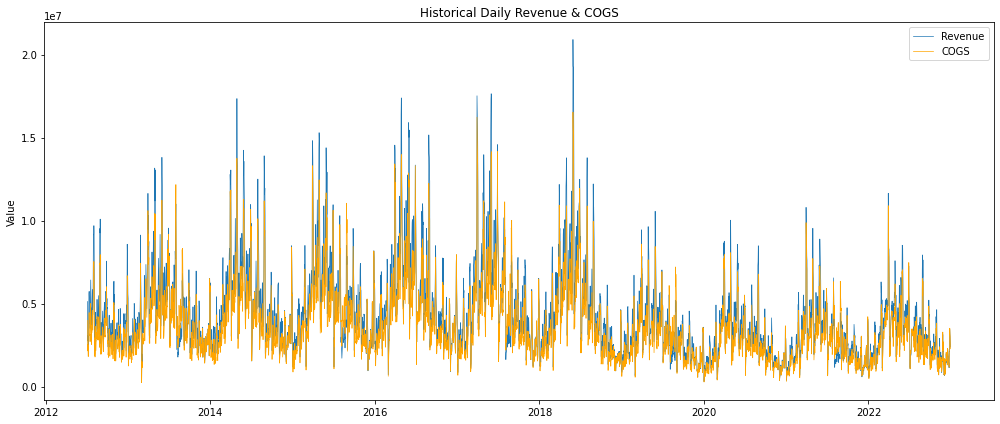

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train['Date'].values, train['Revenue'].values, lw=0.7, label='Revenue')
ax.plot(train['Date'].values, train['COGS'].values, lw=0.7, label='COGS', color='orange')

ax.set_title('Historical Daily Revenue & COGS')
ax.set_ylabel('Value')
ax.legend()

plt.tight_layout()
plt.show()

In [39]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day
train['quarter']    = train['Date'].dt.quarter

test['year'] = test['Date'].dt.year
test['day_of_year'] = test['Date'].dt.dayofyear
test['month'] = test['Date'].dt.month
test['day'] = test['Date'].dt.day
test['quarter'] = test['Date'].dt.quarter

### Sales_full: take mean seasonally

In [40]:
sales_full['day'] = sales_full['date'].dt.day
sales_full.rename(columns={'date':'Date'},inplace=True)
sales_full_ma = sales_full[['Date', 'year','month','quarter','day','revenue_ma7', 'revenue_ma30', 'cogs_ma7','cogs_ma30']]
seasonal_ma = (
    sales_full_ma
    .groupby(['month', 'day'])[
        ['revenue_ma7', 'revenue_ma30', 'cogs_ma7', 'cogs_ma30']
    ]
    .mean()
    .reset_index()
)


### Fourier Transform


In [41]:
def add_fourier_features(df):
    df = df.copy()
    df['doy'] = df['Date'].dt.dayofyear
    df['dow'] = df['Date'].dt.dayofweek
    df['day'] = df['Date'].dt.day
    df['dim'] = df['Date'].dt.days_in_month
    TAU = 2 * np.pi
    for k in range(1, 6):  
        df[f'sin_y{k}'] = np.sin(TAU * k * df['doy'] / 365.25)
        df[f'cos_y{k}'] = np.cos(TAU * k * df['doy'] / 365.25)
    for k in range(1, 3):
        df[f'sin_w{k}'] = np.sin(TAU * k * df['dow'] / 7)
        df[f'cos_w{k}'] = np.cos(TAU * k * df['dow'] / 7)
    for k in range(1, 3):
        df[f'sin_m{k}'] = np.sin(TAU * k * (df['day'] - 1) / df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU * k * (df['day'] - 1) / df['dim'])
    return df

### lag + rolling in the deep

In [42]:
def add_lag_features_train(df, lags=[1, 7, 14, 30], windows=[7, 14, 30]):
    df = df.copy()
    
    # LAGS
    for lag in lags:
        df[f'rev_lag_{lag}'] = df['Revenue'].shift(lag)
        df[f'cogs_lag_{lag}'] = df['COGS'].shift(lag)
    
    # ROLLING (shifted to avoid leakage)
    for w in windows:
        df[f'rev_roll{w}'] = df['Revenue'].shift(1).rolling(w).mean()
        df[f'cogs_roll{w}'] = df['COGS'].shift(1).rolling(w).mean()
    
    return df

def add_lag_features_test(train, test, lags=[1,7,14,30], windows=[7,14,30]):
    df = pd.concat([
        train[['Revenue','COGS']].tail(max(max(lags), max(windows))),
        test
    ], ignore_index=True)
    
    df = add_lag_features_train(df, lags, windows)
    
    return df.iloc[-len(test):].copy()

### Add Supa holiday

In [43]:
TET_DATES = {
    2013:'2013-02-10', 2014:'2014-01-31', 2015:'2015-02-19',
    2016:'2016-02-08', 2017:'2017-01-28', 2018:'2018-02-16',
    2019:'2019-02-05', 2020:'2020-01-25', 2021:'2021-02-12',
    2022:'2022-02-01', 2023:'2023-01-22', 2024:'2024-02-10',
}
VN_FIXED_HOLIDAYS = [
    (1,1,'new_year'), (3,8,'womens_day'), (4,30,'reunification'),
    (5,1,'labor_day'), (9,2,'national_day'), (10,20,'vn_womens_day'),
    (12,24,'christmas_eve'), (12,25,'christmas'),
]

In [44]:
def add_holiday_features(df, tet_dates, fixed_holidays):
    df = df.copy()
    
    df['Date'] = pd.to_datetime(df['Date'])
    
    df['tet_date'] = df['Date'].dt.year.map(tet_dates)
    df['tet_date'] = pd.to_datetime(df['tet_date'])
    df['days_to_tet'] = (df['Date'] - df['tet_date']).dt.days
    
    df['is_tet_period'] = df['days_to_tet'].between(-10, 10).astype(int)
    # smooth effect (strong feature)
    df['tet_weight'] = np.exp(-abs(df['days_to_tet']) / 5)
    
    df['days_to_tet'] = df['days_to_tet'].fillna(999)
    df['tet_weight'] = df['tet_weight'].fillna(0)
    df['is_tet_period'] = df['is_tet_period'].fillna(0)
    
    df = df.drop(columns=['tet_date'])
    
    df['is_holiday'] = 0
    df['near_holiday'] = 0
    
    for m, d, name in fixed_holidays:
        holiday_date = pd.to_datetime(
            df['Date'].dt.year.astype(str) + f'-{m:02d}-{d:02d}'
        )
        df.loc[df['Date'] == holiday_date, 'is_holiday'] = 1
    
        df['near_holiday'] += (
            (df['Date'] - holiday_date).abs().dt.days <= 3
        ).astype(int)
    df['is_holiday'] = df['is_holiday'].fillna(0)
    df['near_holiday'] = df['near_holiday'].fillna(0)

    day = df['Date'].dt.day
    month_end = df['Date'].dt.days_in_month

    df['is_month_start'] = (day <= 3).astype(int)
    df['is_month_end']   = (day >= month_end - 2).astype(int)
    df['is_weekend']     = (df['Date'].dt.dayofweek >= 5).astype(int)
    df['is_summer']      = ((df['Date'].dt.month >= 4) & (df['Date'].dt.month <= 6)).astype(int) 
    #covid flag
    df['pre_covid']   = (df['Date'] < '2020-03-01').astype(int)
    df['is_covid']    = ((df['Date'] >= '2020-03-01') & (df['Date'] <= '2021-12-31')).astype(int)
    df['post_covid']  = ((df['Date'] >= '2022-01-01') & (df['Date'] <= '2022-12-31')).astype(int)
    return df


### Add promo wwindow

In [45]:
PROMO_SCHEDULE = [
    ('spring_sale',   3, 18, 30, 12,  True),
    ('mid_year',      6, 23, 29, 18,  True),
    ('fall_launch',   8, 30, 32, 10,  True),
    ('year_end',     11, 18, 45, 20,  True),
    ('urban_blowout', 7, 30, 33, None,'odd'),
    ('rural_special', 1, 30, 30, 15,  'odd'),
]

In [46]:
def add_promo_window(df):
    df = df.copy()
    d   = pd.to_datetime(df['Date'])
    yrs = sorted(d.dt.year.unique())

    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_promo = np.zeros(len(df), dtype=int)
        since    = np.full(len(df), -1.0)
        until    = np.full(len(df), -1.0)
        discount = np.zeros(len(df))

        for y in range(min(yrs) - 1, max(yrs) + 2):
            if recur == 'odd' and y % 2 == 0:
                continue

            start = pd.Timestamp(year=y, month=sm, day=sd)
            end   = start + pd.Timedelta(days=dur)
            mask  = (d >= start) & (d <= end)

            in_promo[mask] = 1
            since[mask]    = (d[mask] - start).dt.days
            until[mask]    = (end - d[mask]).dt.days
            discount[mask] = disc if disc is not None else 0

        df[f'promo_{name}']       = in_promo
        df[f'promo_{name}_since'] = since
        df[f'promo_{name}_until'] = until
        df[f'promo_{name}_disc']  = discount

    df['is_odd_year'] = (d.dt.year % 2).astype(int)
    
    return df

### Adding all feature 

In [47]:
#fourier
train = add_fourier_features(train)
test  = add_fourier_features(test)
#lag_feare
train = add_lag_features_train(train)
train = train.dropna()
test = add_lag_features_test(train, test)

# holiday
train = add_holiday_features(train, TET_DATES, VN_FIXED_HOLIDAYS)
test  = add_holiday_features(test,  TET_DATES, VN_FIXED_HOLIDAYS)

#promo
train = add_promo_window(train)
test = add_promo_window(test)

### Annual Mean

In [48]:
annual_means = train.groupby('year')[['Revenue', 'COGS']].transform('mean')
train['rev_norm'] = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS'] / annual_means['COGS']

seasonal = (
    train
    .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
    .rename(columns={
        'rev_norm': 'rev_seasonal',
        'cogs_norm': 'cogs_seasonal'
    })
)
quartely = (
    train
    .groupby(['year', 'quarter'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
    .rename(columns={
        'rev_norm': 'rev_quarterly',
        'cogs_norm': 'cogs_quarterly'
    })
)

train = train.merge(seasonal, on=['month', 'day'], how='left')
train = train.merge(quartely, on = ['year', 'quarter'], how = 'left')
train = train.merge(seasonal_ma, on = ['month', 'day'], how = 'left')


test = test.merge(seasonal, on=['month', 'day'], how='left')
test = test.merge(quartely, on = ['year', 'quarter'], how = 'left')
test = test.merge(seasonal_ma, on = ['month', 'day'], how = 'left')

test[['rev_seasonal', 'cogs_seasonal','rev_quarterly','cogs_quarterly']] = test[['rev_seasonal', 'cogs_seasonal','rev_quarterly','cogs_quarterly']].fillna(1.0)




In [49]:
fourier_cols = [col for col in train.columns if 'sin_' in col or 'cos_' in col]
lagroll_cols = [col for col in train.columns if 'lag_' in col or 'roll' in col]
holiday_cols = [col for col in train.columns if 'tet' in col or 'holiday' in col]
promo_cols = [col for col in train.columns if 'promo' in col]
covid_cols = [col for col in train.columns if 'covid' in col]
features_ridge = [
    'day_of_year', 'dow', 'dim', 'day',
    'rev_seasonal', 
    'cogs_seasonal',
    'revenue_ma7', 'revenue_ma30', 'cogs_ma7', 'cogs_ma30', 'is_holiday','is_tet_period','days_to_tet','near_holiday',
    'is_month_start', 'is_month_end','is_weekend', 'is_summer',
] + fourier_cols + promo_cols
features = [
    'day_of_year','dow','dim', 'day',
    'rev_seasonal',
    'cogs_seasonal',
    'revenue_ma7', 'revenue_ma30', 'cogs_ma7', 'cogs_ma30', 'is_holiday','is_tet_period','days_to_tet','near_holiday',
    'is_month_start', 'is_month_end','is_weekend', 'is_summer',
] + fourier_cols + promo_cols
#this for light gbm
best_params = {
    "n_estimators": 50, 
    "learning_rate": 0.05,
    "max_depth": 64,         
    "num_leaves": 32,         
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_samples": 20,
    "reg_alpha": 0.1,        
    "reg_lambda": 1.0,        
    "random_state": 42,
    "verbosity":-1
}
xgb_params = {
    "n_estimators": 50,
    "learning_rate": 0.05,
    "max_depth": 64,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.1,              
    "min_child_weight": 5,     
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": 42,
    "tree_method": "hist",
}
ridge_params = {
    "alpha": 10.0,       
    "fit_intercept": True,
    "solver": "auto"
}

### Training + Ensemble 3 reg model

In [50]:
# LightGBM
lgb_revenue = LGBMRegressor(**best_params)
lgb_cogs    = LGBMRegressor(**best_params)

# XGBoost (same params mostly OK)
xgb_revenue = XGBRegressor(**xgb_params)
xgb_cogs    = XGBRegressor(**xgb_params)

#Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[features_ridge])
X_test_scaled  = scaler.transform(test[features_ridge])
ridge_revenue = Ridge(**ridge_params)
ridge_cogs    = Ridge(**ridge_params)

# Fit
lgb_revenue.fit(train[features], train['Revenue'])
lgb_cogs.fit(train[features], train['COGS'])

xgb_revenue.fit(train[features], train['Revenue'])
xgb_cogs.fit(train[features], train['COGS'])

ridge_revenue.fit(X_train_scaled, train['Revenue'])
ridge_cogs.fit(X_train_scaled, train['COGS'])

# LGB predictions
test['rev_lgb']  = lgb_revenue.predict(test[features])
test['cogs_lgb'] = lgb_cogs.predict(test[features])

# XGB predictions
test['rev_xgb']  = xgb_revenue.predict(test[features])
test['cogs_xgb'] = xgb_cogs.predict(test[features])

# Ridge pred
test['rev_ridge']  = ridge_revenue.predict(X_test_scaled)
test['cogs_ridge'] = ridge_cogs.predict(X_test_scaled)

#Ensemble annual
test['Revenue'] = (test['rev_lgb']*0.5+ test['rev_xgb']*0.25 + test['rev_ridge']*0.25) 
test['COGS']    = (test['cogs_lgb']*0.5 + test['cogs_xgb']*0.25 + test['cogs_ridge']*0.25) 

test['Revenue'] = test['Revenue'].clip(lower=1e-6)
test['COGS']    = test['COGS'].clip(lower=1e-6)

### Cross validate

In [51]:
def eval_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:20s} | MAE: {mae:10.2f} | RMSE: {rmse:10.2f} | R2: {r2:.4f}")
    return mae, rmse, r2

In [52]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, val_idx) in enumerate(kf.split(train)):
    tr, val = train.iloc[tr_idx], train.iloc[val_idx]
    scaler     = StandardScaler()
    tr_scaled  = scaler.fit_transform(tr[features_ridge])
    val_scaled = scaler.transform(val[features_ridge])

    lgb_rev = LGBMRegressor(**best_params).fit(tr[features], tr['Revenue'])
    lgb_cog = LGBMRegressor(**best_params).fit(tr[features], tr['COGS'])
    xgb_rev = XGBRegressor(**xgb_params).fit(tr[features],  tr['Revenue'])
    xgb_cog = XGBRegressor(**xgb_params).fit(tr[features],  tr['COGS'])
    rid_rev = Ridge(**ridge_params).fit(tr_scaled, tr['Revenue'])
    rid_cog = Ridge(**ridge_params).fit(tr_scaled, tr['COGS'])

    rev_lgb   = lgb_rev.predict(val[features])
    rev_xgb   = xgb_rev.predict(val[features])
    rev_ridge = rid_rev.predict(val_scaled)
    cog_lgb   = lgb_cog.predict(val[features])
    cog_xgb   = xgb_cog.predict(val[features])
    cog_ridge = rid_cog.predict(val_scaled)

    rev_ens = (rev_lgb*0.5 + rev_xgb*0.25 + rev_ridge*0.25).clip(1e-6)
    cog_ens = (cog_lgb*0.5 + cog_xgb*0.25 + cog_ridge*0.25).clip(1e-6)

    print(f"\n--- Fold {fold+1} ---")
    for label, yt, yp in [
        ('LGB   Revenue', val['Revenue'], rev_lgb),
        ('XGB   Revenue', val['Revenue'], rev_xgb),
        ('Ridge Revenue', val['Revenue'], rev_ridge),
        ('Ens   Revenue', val['Revenue'], rev_ens),
    ]:
        eval_metrics(yt, yp, label)


--- Fold 1 ---
LGB   Revenue        | MAE: 1180861.32 | RMSE: 1540881.66 | R2: 0.6433
XGB   Revenue        | MAE: 1347074.96 | RMSE: 1743841.62 | R2: 0.5431
Ridge Revenue        | MAE: 1133868.97 | RMSE: 1464842.47 | R2: 0.6776
Ens   Revenue        | MAE: 1200192.83 | RMSE: 1554996.50 | R2: 0.6367

--- Fold 2 ---
LGB   Revenue        | MAE: 1247411.56 | RMSE: 1656504.10 | R2: 0.6094
XGB   Revenue        | MAE: 1428859.62 | RMSE: 1874298.72 | R2: 0.5000
Ridge Revenue        | MAE: 1210207.85 | RMSE: 1584544.30 | R2: 0.6426
Ens   Revenue        | MAE: 1270942.94 | RMSE: 1674327.72 | R2: 0.6010

--- Fold 3 ---
LGB   Revenue        | MAE: 1206106.54 | RMSE: 1643778.22 | R2: 0.6451
XGB   Revenue        | MAE: 1397946.08 | RMSE: 1861258.53 | R2: 0.5450
Ridge Revenue        | MAE: 1150556.95 | RMSE: 1572703.78 | R2: 0.6751
Ens   Revenue        | MAE: 1228251.84 | RMSE: 1660640.53 | R2: 0.6378

--- Fold 4 ---
LGB   Revenue        | MAE: 1210604.59 | RMSE: 1602766.00 | R2: 0.6286
XGB   Revenue

### Baseline formula + ensemble 3 model with baseline

In [53]:
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
full_years = annual.loc[2013:2022]
base_rev  = annual.loc[2022, 'Revenue']  / 365.25
base_cogs = annual.loc[2022, 'COGS']     / 365.25

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()
#1.15 1.2
growth_rev  = (1.1+yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1.1+yoy_cogs).prod() ** (1 / len(yoy_cogs))

test['years_ahead'] = test['year'] - 2022
test['Revenue_baseline'] = (base_rev  * growth_rev**test['years_ahead']  * test['rev_seasonal'] ).round(2)
test['COGS_baseline']    = (base_cogs * growth_cogs**test['years_ahead'] * test['cogs_seasonal']).round(2)

test['Revenue'] = test['Revenue']*0.8 + test['Revenue_baseline']*0.2
test['COGS'] = test['COGS']*0.8 + test['COGS_baseline']*0.2

### Predict plot

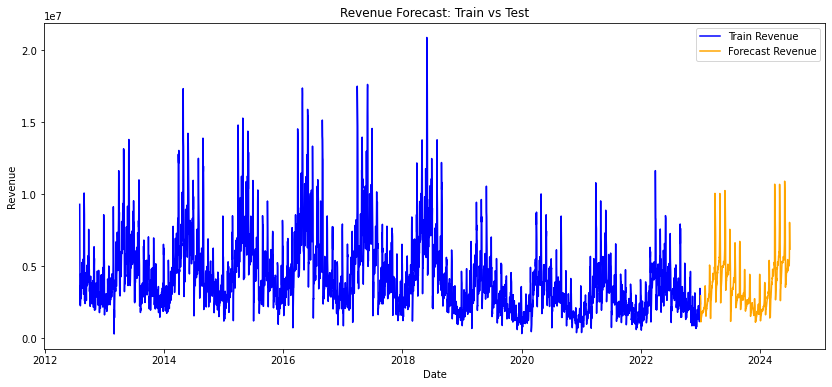

In [54]:
train_plot = train[['Date', 'Revenue']].copy()
train_plot['type'] = 'train'

test_plot = test[['Date', 'Revenue_baseline']].copy()
test_plot['type'] = 'test'

full_plot = pd.concat([train_plot, test_plot], ignore_index=True)
full_plot = full_plot.sort_values('Date')


plt.figure(figsize=(14,6))

# train actual
plt.plot(
    train_plot['Date'].values,
    train_plot['Revenue'].values,
    label='Train Revenue',
    color='blue'
)

# test forecast
plt.plot(
    test_plot['Date'].values,
    test_plot['Revenue_baseline'].values,
    label='Forecast Revenue',
    color='orange'
)

plt.title("Revenue Forecast: Train vs Test")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()

### Submission phase


In [57]:
submission = test[['Date', 'Revenue', 'COGS']].copy()
SAVE_DIR = os.path.join(DATA_DIR, 'submission.csv')
submission.to_csv(SAVE_DIR, index=False)
submission

,Date,Revenue,COGS
0,2023-01-01,3.642146e+06,3.208079e+06
1,2023-01-02,1.932257e+06,1.677772e+06
2,2023-01-03,1.655900e+06,1.404917e+06
3,2023-01-04,1.714357e+06,1.410876e+06
4,2023-01-05,1.757381e+06,1.455196e+06
...,...,...,...
543,2024-06-27,6.632735e+06,6.377799e+06
544,2024-06-28,5.965956e+06,5.662146e+06
545,2024-06-29,9.057200e+06,8.544135e+06
546,2024-06-30,7.268937e+06,7.065541e+06


### SHAP

In [ ]:
import shap
explainer = shap.TreeExplainer(lgb_revenue)
shap_values = explainer(train[features])  

shap_df = pd.DataFrame(
    shap_values.values,
    columns=features,
    index=train.index
)
shap_df.head(5)

,day_of_year,dow,dim,day,rev_seasonal,cogs_seasonal,revenue_ma7,revenue_ma30,cogs_ma7,cogs_ma30,...,promo_year_end_until,promo_year_end_disc,promo_urban_blowout,promo_urban_blowout_since,promo_urban_blowout_until,promo_urban_blowout_disc,promo_rural_special,promo_rural_special_since,promo_rural_special_until,promo_rural_special_disc
0,92816.222017,-36846.909851,1073.817587,2915.448876,1.362975e+06,393607.469169,137133.924363,12345.029185,328941.364532,-487.562146,...,0.0,0.0,16697.521398,31745.418049,3115.396593,0.0,0.0,-54.832946,0.0,0.0
1,54780.459739,-164102.031818,296.508796,-18468.429425,4.046679e+05,344956.781374,113336.417562,4714.172825,203659.499961,1208.586527,...,0.0,0.0,19968.040764,20125.756503,3109.572192,0.0,0.0,-54.832946,0.0,0.0
2,12860.081604,-78073.345516,110.493793,-18621.855439,-9.746316e+05,-194966.568366,14385.573787,4975.666478,96783.226146,1243.578151,...,0.0,0.0,23777.789030,12988.094734,2405.394535,0.0,0.0,-54.832946,0.0,0.0
3,12551.976681,61646.502044,110.493793,-22057.977763,-8.618832e+05,-169991.494245,15686.575243,4807.869807,98598.976431,226.726129,...,0.0,0.0,27799.989704,14727.995186,5810.988272,0.0,0.0,-54.832946,0.0,0.0
4,13719.541584,61142.404500,110.493793,-21799.169970,-9.010048e+05,-162693.183991,8324.672297,994.840969,48718.947656,-35.322522,...,0.0,0.0,26730.932483,13477.786126,5798.781290,0.0,0.0,-54.832946,0.0,0.0


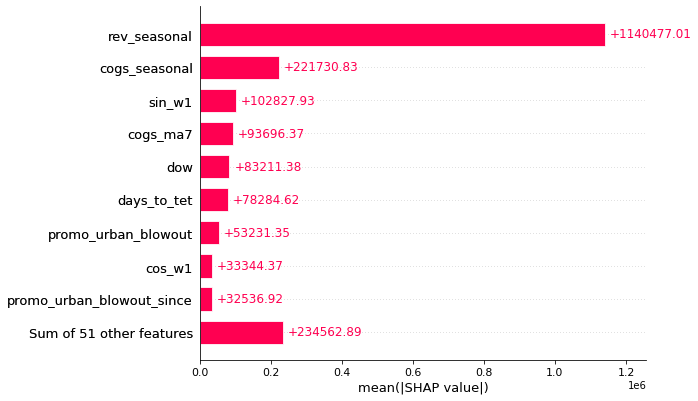

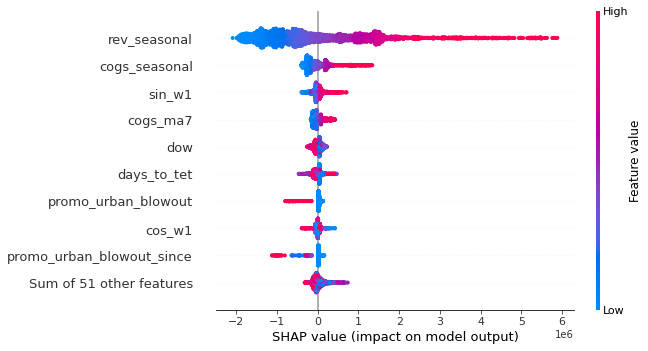

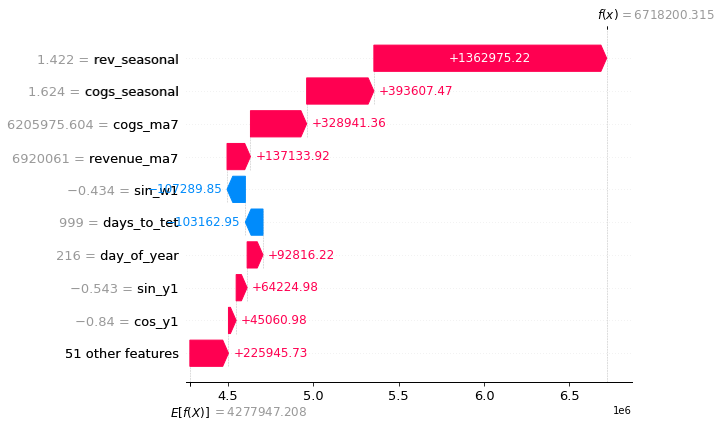

In [ ]:
shap_rev = explainer(train[features])
shap.plots.bar(shap_rev)
shap.plots.beeswarm(shap_rev)
shap.plots.waterfall(shap_rev[0])